In [1]:
pip install opencv-python "numpy<2" matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure

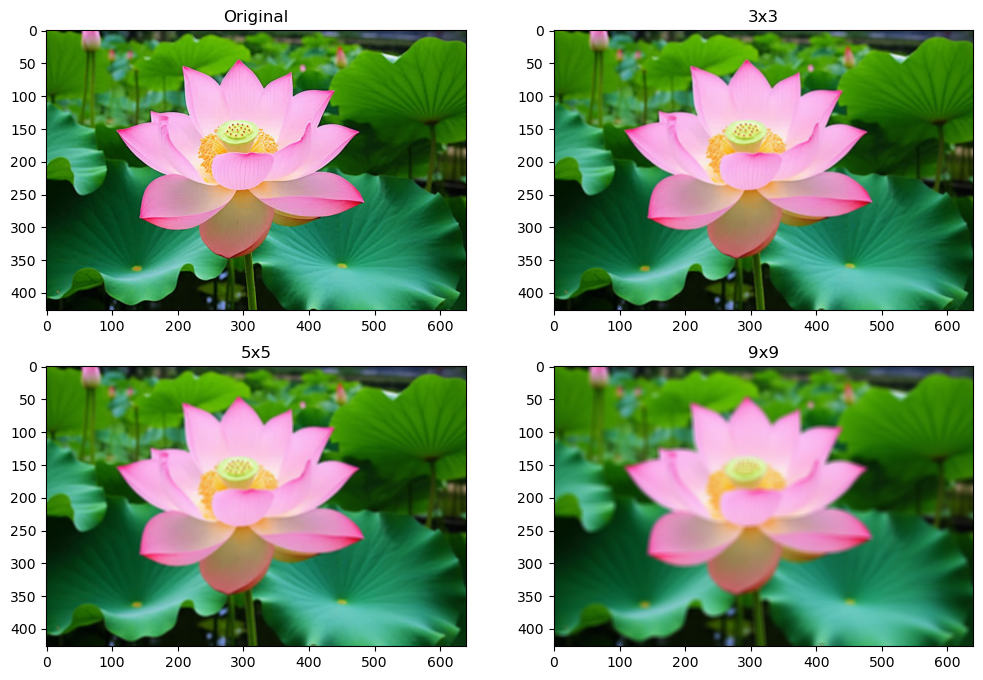

In [3]:
img = cv2.imread('/Users/230070/Downloads/lotus.jpg')

blur3 = cv2.blur(img, (3,3))
blur5 = cv2.blur(img, (5,5))
blur9 = cv2.blur(img, (9,9))

plt.figure(figsize=(12,8))
plt.subplot(221); plt.imshow(img[...,::-1]); plt.title("Original")
plt.subplot(222); plt.imshow(blur3[...,::-1]); plt.title("3x3")
plt.subplot(223); plt.imshow(blur5[...,::-1]); plt.title("5x5")
plt.subplot(224); plt.imshow(blur9[...,::-1]); plt.title("9x9")
plt.show()

# Challenge 2

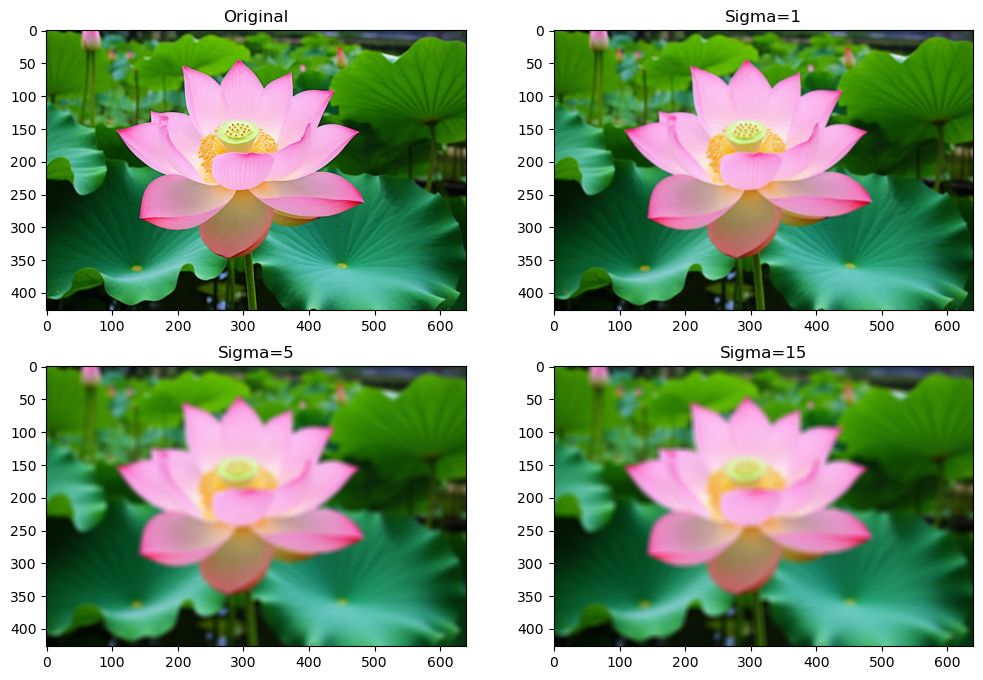

In [4]:
gauss1 = cv2.GaussianBlur(img, (11,11), 1)
gauss5 = cv2.GaussianBlur(img, (11,11), 5)
gauss15 = cv2.GaussianBlur(img, (11,11), 15)

plt.figure(figsize=(12,8))
plt.subplot(221); plt.imshow(img[...,::-1]);plt.title("Original")
plt.subplot(222); plt.imshow(gauss1[...,::-1]);plt.title("Sigma=1")
plt.subplot(223);plt.imshow(gauss5[...,::-1]); plt.title("Sigma=5")
plt.subplot(224); plt.imshow(gauss15[...,::-1]); plt.title("Sigma=15")
plt.show()

# Challenge 3

ERROR! Session/line number was not unique in database. History logging moved to new session 2


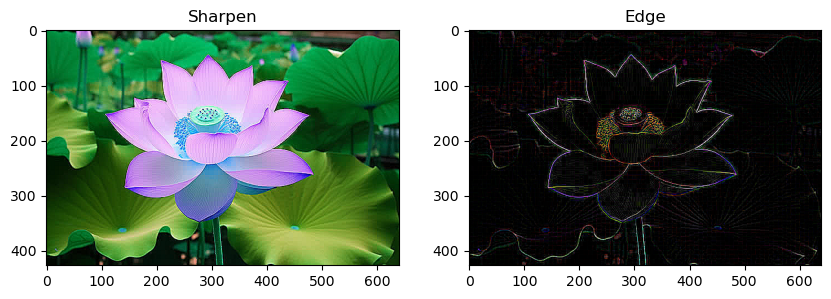

In [5]:
kernel_sharp = np.array([[0,-1,0],
                         [-1,5,-1],
                         [0,-1,0]])

kernel_edge = np.array([[-1,-1,-1],
                        [-1,8,-1],
                        [-1,-1,-1]])

sharp = cv2.filter2D(img,-1,kernel_sharp)
edges = cv2.filter2D(img,-1,kernel_edge)

plt.figure(figsize=(10,5))
plt.subplot(121); plt.imshow(sharp); plt.title("Sharpen")
plt.subplot(122); plt.imshow(edges); plt.title("Edge")
plt.show()

# Challenge 4

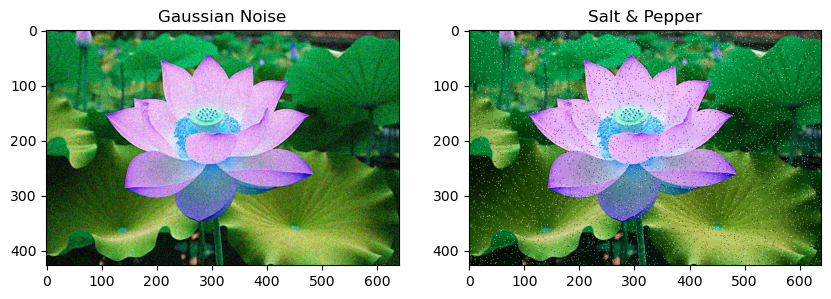

In [6]:
noise = np.random.normal(0,25,img.shape)
noisy = img + noise
noisy = np.clip(noisy,0,255).astype(np.uint8)

sp = img.copy()
prob = 0.02
rand = np.random.rand(*img.shape[:2])
sp[rand < prob] = 0
sp[rand > 1-prob] = 255

plt.figure(figsize=(10,5))
plt.subplot(121); plt.imshow(noisy); plt.title("Gaussian Noise")
plt.subplot(122); plt.imshow(sp); plt.title("Salt & Pepper")
plt.show()

# Challenge 5

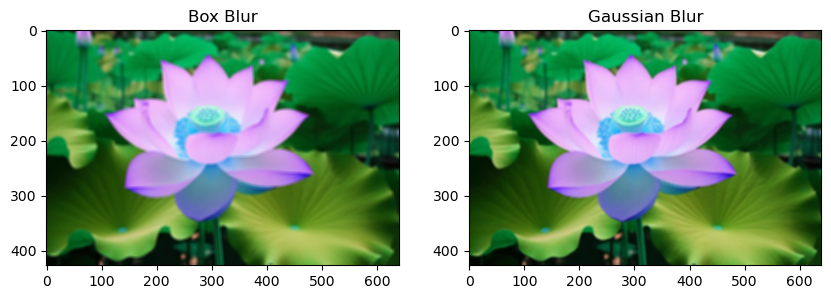

In [7]:
box = cv2.blur(img,(7,7))
gauss = cv2.GaussianBlur(img,(7,7),2)

plt.figure(figsize=(10,5))
plt.subplot(121); plt.imshow(box); plt.title("Box Blur")
plt.subplot(122); plt.imshow(gauss); plt.title("Gaussian Blur")
plt.show()

# Challenge 6

In [8]:
import time

start = time.time()
for i in range(50):
    cv2.filter2D(img,-1,kernel_sharp)
print("filter2D avg time:", (time.time()-start)/50)

start = time.time()
for i in range(50):
    cv2.GaussianBlur(img,(7,7),2)
print("Gaussian avg time:", (time.time()-start)/50)

filter2D avg time: 0.0010385417938232422
Gaussian avg time: 0.00042017459869384764


# Challenge 7

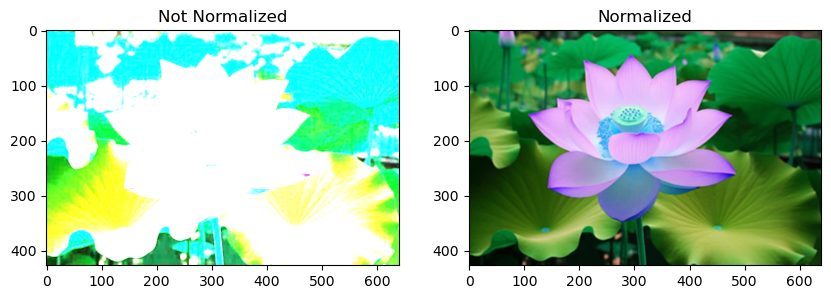

In [9]:
kernel_bad = np.ones((3,3))
bright = cv2.filter2D(img,-1,kernel_bad)

kernel_good = kernel_bad / kernel_bad.sum()
fixed = cv2.filter2D(img,-1,kernel_good)

plt.figure(figsize=(10,5))
plt.subplot(121); plt.imshow(bright); plt.title("Not Normalized")
plt.subplot(122); plt.imshow(fixed); plt.title("Normalized")
plt.show()